In [18]:
import matplotlib
matplotlib.rcParams._get = matplotlib.rcParams.get
%matplotlib inline

# Master Notebook: Paper Figures
This notebook generates all data panels for the paper figures.

## Imports & Setup

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import scHopfield as sch

os.chdir('/Users/bernaljp/Documents/SCH/notebooks/core')

DATA_DIR = "/Users/bernaljp/Documents/SCHData"
SAVE_DIR = "./results/paper_figures"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)

## Section 1: Figure 1 (Overview & Energy Landscapes)
Load primary dataset (`hematopoiesis.h5ad` or pancreas) and generate UMAP, Velocity, and Energy plots.

In [30]:
_local_path = f"{DATA_DIR}/hematopoiesis.h5ad"
if os.path.exists(_local_path):
    print("Loading local hematopoiesis data...")
    adata = sc.read_h5ad(_local_path)
else:
    print("Downloading hematopoiesis data via dynamo...")
    import dynamo as dyn
    adata = dyn.sample_data.hematopoiesis(filename='hematopoiesis.h5ad')

print("Plotting UMAP...")
sc.pl.umap(adata, color='cell_type', show=False)
plt.savefig(f"{SAVE_DIR}/fig1_umap.pdf", bbox_inches='tight')
plt.close()

print("Plotting Velocity Stream...")
scv.pl.velocity_embedding_stream(adata, basis='umap', color='cell_type', show=False)
plt.savefig(f"{SAVE_DIR}/fig1_velocity.png", bbox_inches='tight', dpi=300)
plt.close()

Loading local hematopoiesis data...
Plotting UMAP...


Plotting Velocity Stream...


In [4]:
print("X_umap finite:", np.isfinite(adata.obsm['X_umap']).all())

X_umap finite: True


In [39]:
print("Loading pre-trained scHopfield model on hematopoiesis data...")
result = sch.tl.load_model(adata, f"{DATA_DIR}/model_hematopoiesis.h5sch")
if result is not None:
    adata = result

print("Preprocessing: Removing genes with NaNs in the model...")
nan_mask = adata.var['I_Ery'].isna()
if nan_mask.any():
    print(f"Removing {nan_mask.sum()} genes with NaNs in I_Ery")
    adata = adata[:, ~nan_mask].copy()

print(f"Data shape after removing NaNs: {adata.shape}")

print("Computing energies...")
sch.tl.compute_energies(adata, cluster_key='cell_type', spliced_key='M_t')

Loading pre-trained scHopfield model on hematopoiesis data...
Preprocessing: Removing genes with NaNs in the model...
Removing 228 genes with NaNs in I_Ery
Data shape after removing NaNs: (1947, 1728)
Computing energies...


In [3]:
import os; print(os.getcwd())

/


Plotting Velocity Stream...


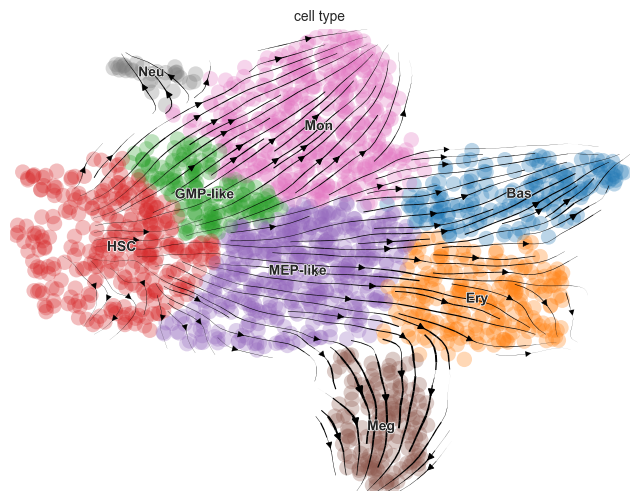

Velocity stream plotted and saved!
Plotting UMAP...


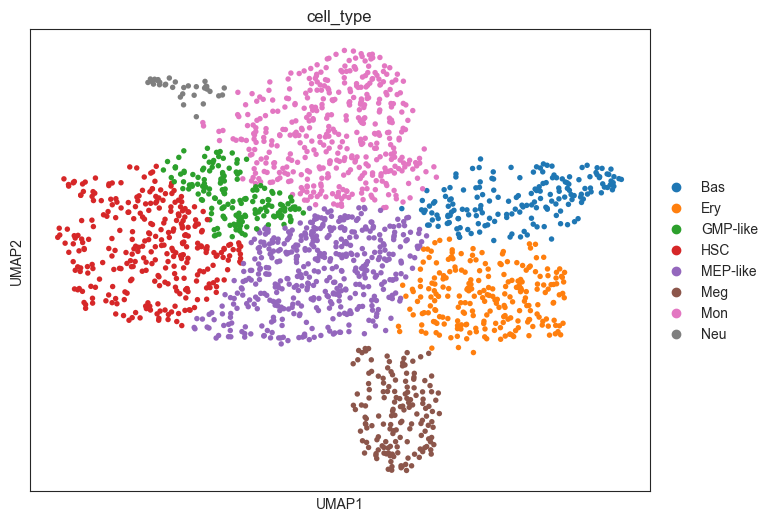

UMAP plotted and saved!
Computing and Plotting Energy Landscape...


Error plotting energies: Figure.set() got an unexpected keyword argument 'cmap'


In [23]:
print("Plotting Velocity Stream...")
fig, ax = plt.subplots(figsize=(8, 6))
scv.pl.velocity_embedding_stream(adata, basis='umap', color='cell_type', ax=ax, show=False)
plt.savefig(f"{SAVE_DIR}/fig1_velocity_stream.png", bbox_inches='tight', dpi=300)
plt.show()
print("Velocity stream plotted and saved!")

print("Plotting UMAP...")
fig, ax = plt.subplots(figsize=(8, 6))
sc.pl.umap(adata, color='cell_type', ax=ax, show=False)
plt.savefig(f"{SAVE_DIR}/fig1_umap.png", bbox_inches='tight', dpi=300)
plt.show()
print("UMAP plotted and saved!")

print("Computing and Plotting Energy Landscape...")
try:
    sch.tl.compute_energies(adata, cluster_key='cell_type', spliced_key='spliced')
except Exception as e:
    print(f"Error computing energies: {e}")

try:
    fig = sch.pl.plot_energy_scatters(
        adata,
        cluster_key='cell_type',
        plot_energy='total',
        cmap='viridis',
        basis='umap',
        s=50,
        alpha=0.8,
        show=False
    )
    # The plot_energy_scatters returns a figure or axes, let's just save the current figure
    plt.savefig(f"{SAVE_DIR}/fig1_energy_landscape.png", bbox_inches='tight', dpi=300)
    plt.show()
    print("Energy landscape plotted and saved!")
except Exception as e:
    print(f"Error plotting energies: {e}")


Plotting Energy Landscape (3D Scatters)...


Saved 3D scatter landscape as fig1_energy_landscape_scatter.png


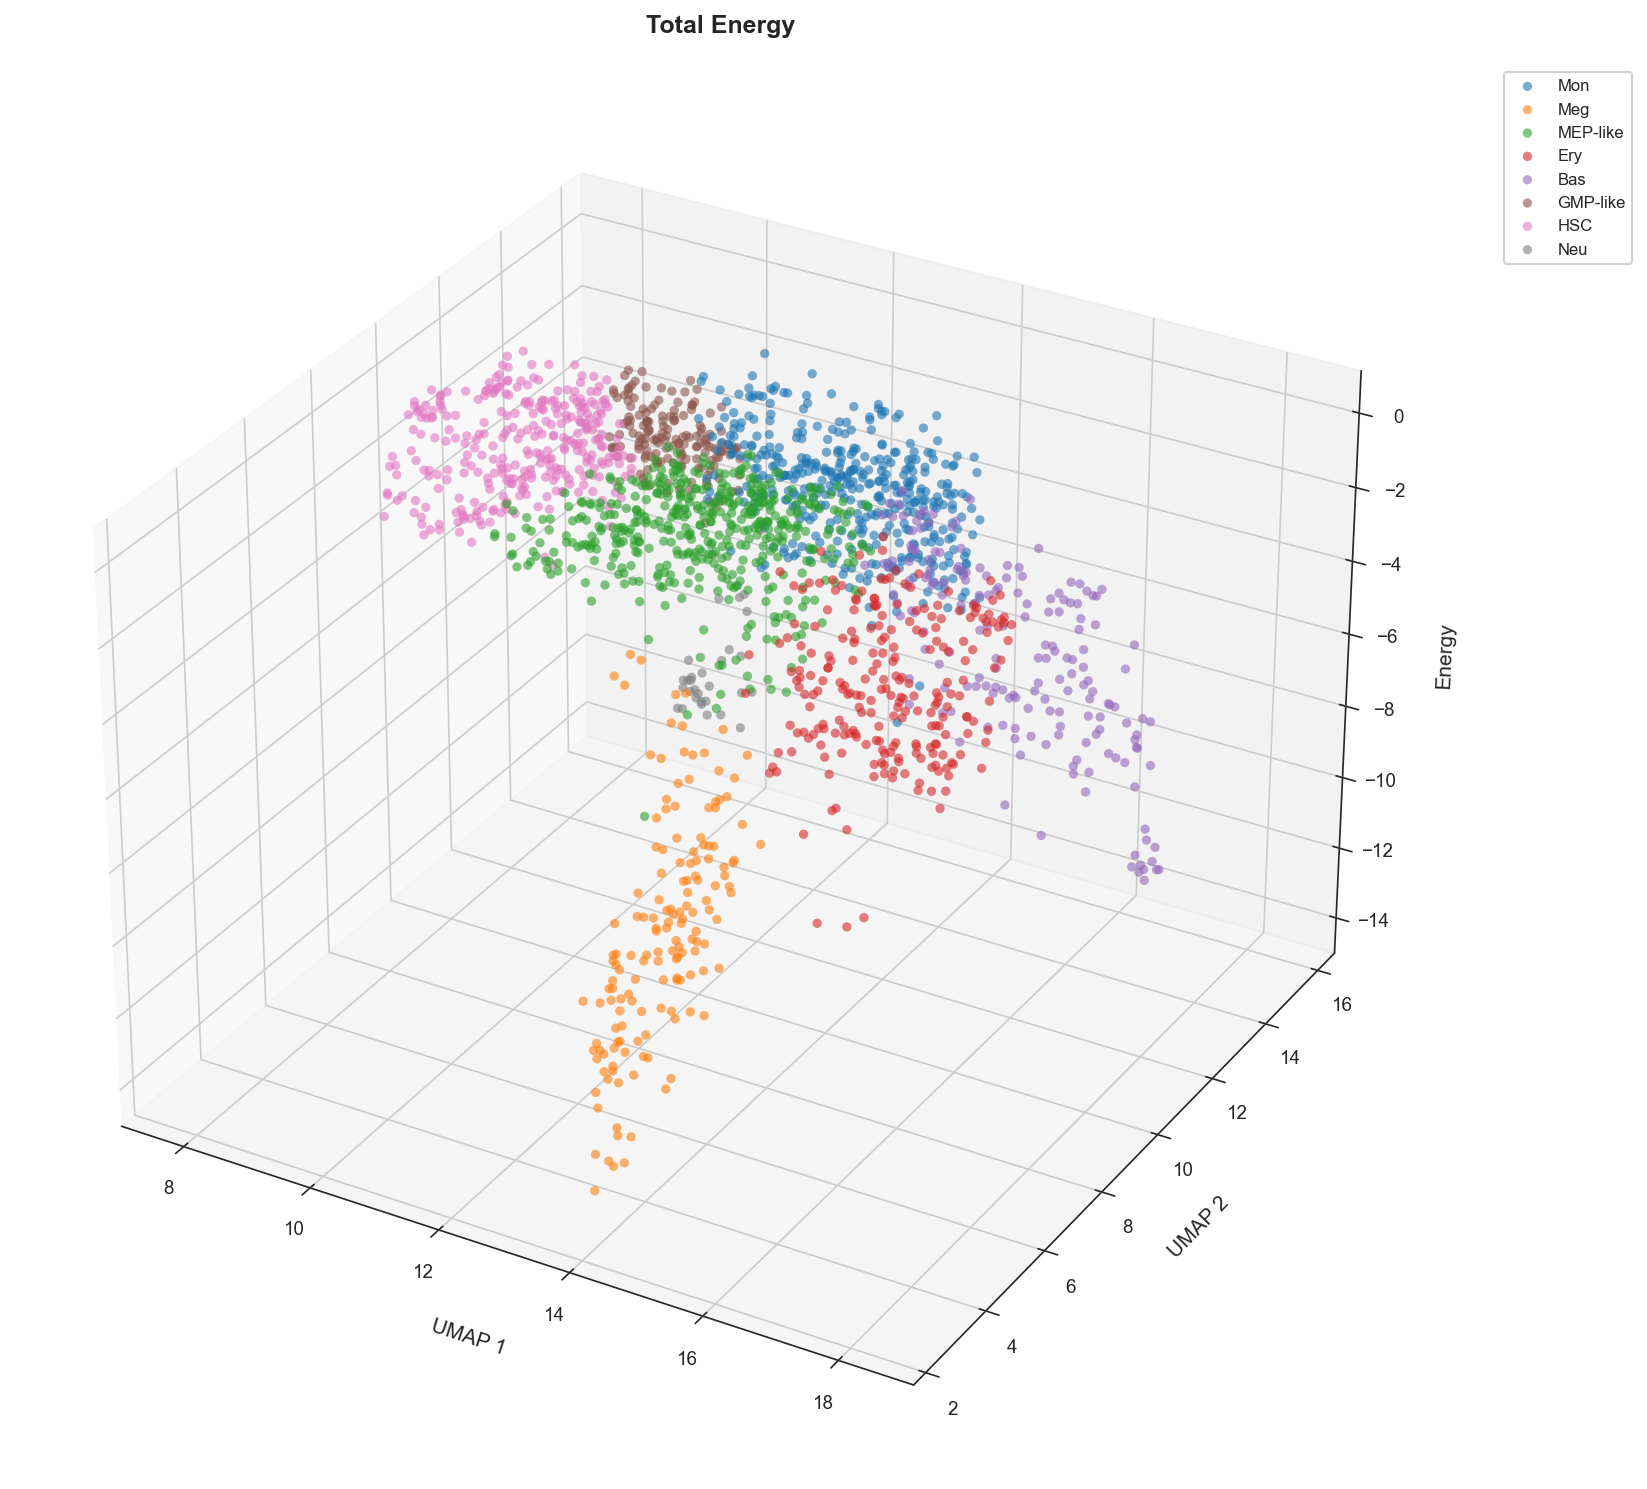

In [45]:
print("Plotting Energy Landscape (3D Scatters)...")
try:
    ax_or_fig = sch.pl.plot_energy_scatters(
        adata,
        cluster_key='cell_type',
        plot_energy='total',
        figsize=(15, 10)
    )
    fig = ax_or_fig.figure if hasattr(ax_or_fig, 'figure') else ax_or_fig
    plt.tight_layout()
    fig.savefig("fig1_energy_landscape_scatter.png", dpi=300, bbox_inches='tight')
    print("Saved 3D scatter landscape as fig1_energy_landscape_scatter.png")
except Exception as e:
    print(f"Error plotting 3D scatter: {e}")

In [40]:
print("NaNs in total:", adata.obs['energy_total'].isna().sum())
print("NaNs in int:", adata.obs['energy_interaction'].isna().sum())
print("NaNs in deg:", adata.obs['energy_degradation'].isna().sum())
print("NaNs in bias:", adata.obs['energy_bias'].isna().sum())

NaNs in total: 0
NaNs in int: 0
NaNs in deg: 0
NaNs in bias: 0


Running Validation Circuits (Toggle & Repressilator)...
A.a  Toggle switch


  full    : sign_acc=1.000  corr=1.0000  frob=0.001
  partial : sign_acc=1.000  corr=1.0000  frob=0.001
  none    : sign_acc=1.000  corr=1.0000  frob=0.001
  bifurcation sweep ...


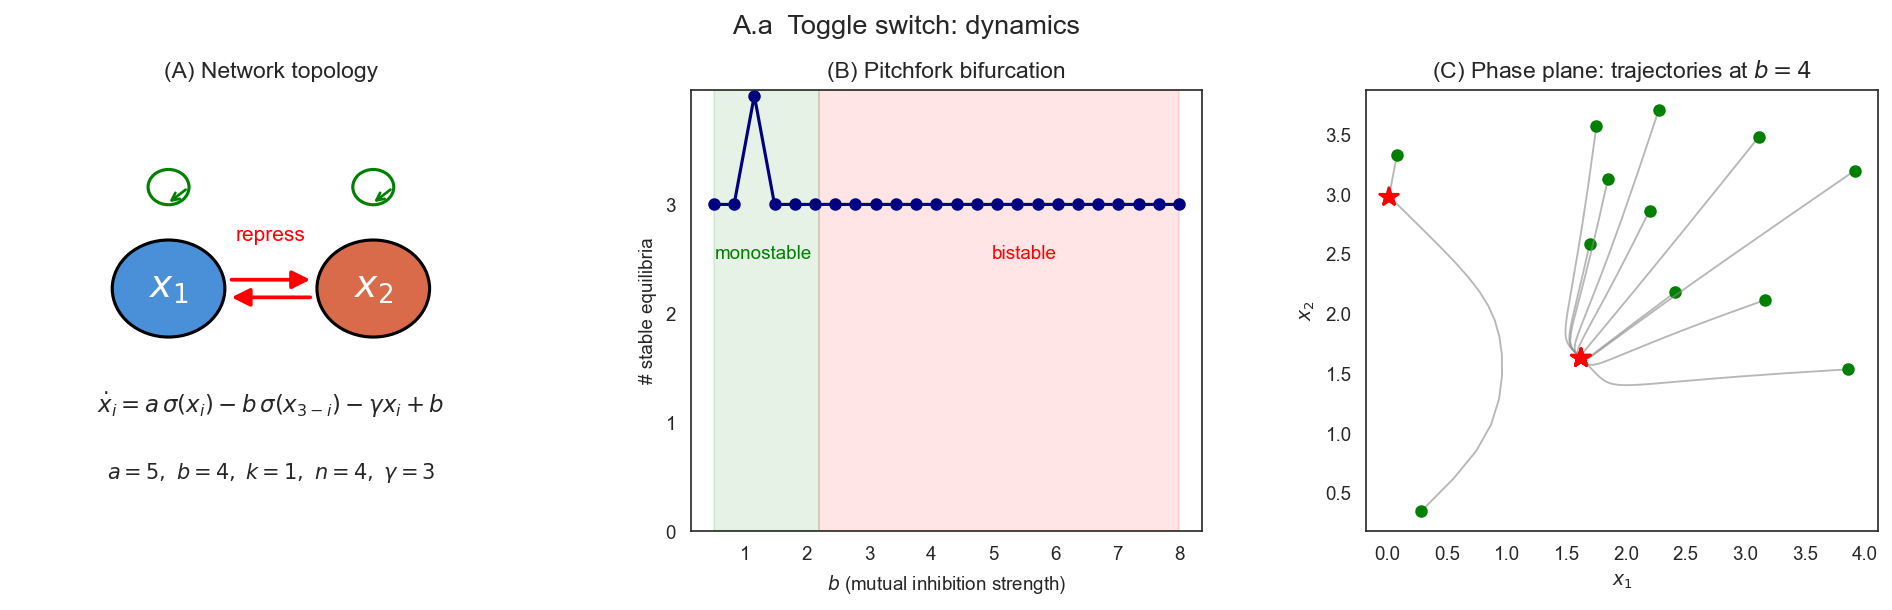

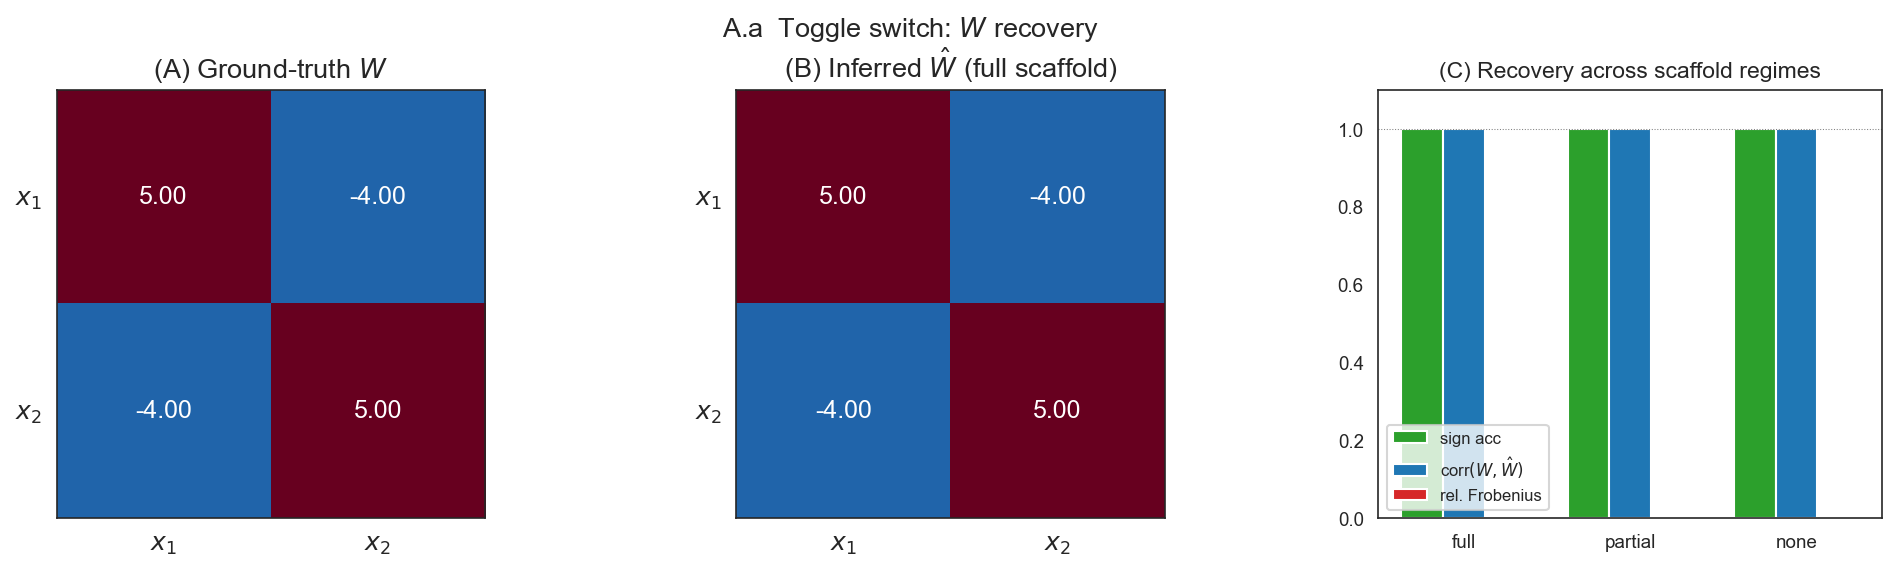


A.b  Elowitz repressilator


  full    : sign_acc=1.000  asym=1.00
  partial : sign_acc=1.000  asym=1.00
  none    : sign_acc=1.000  asym=1.00


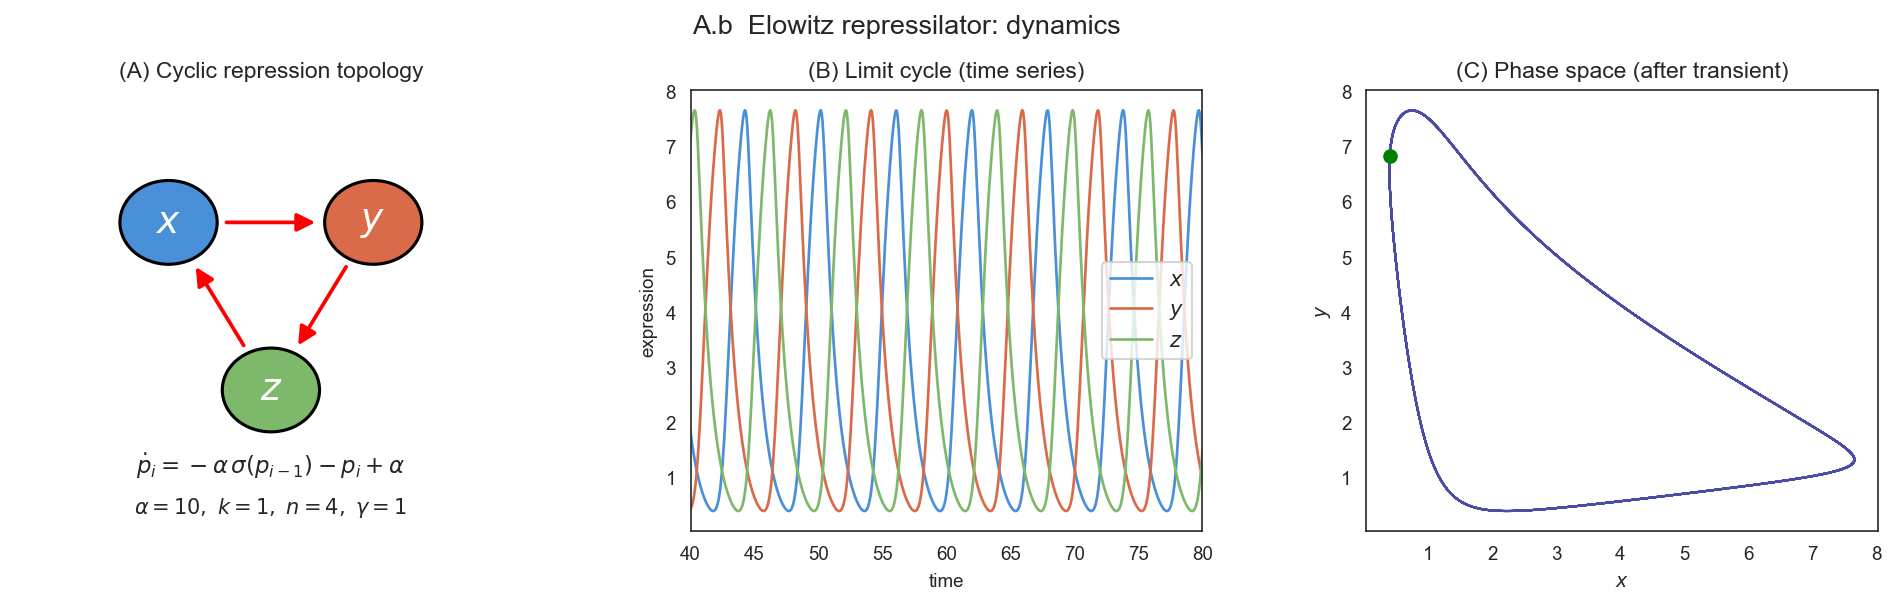

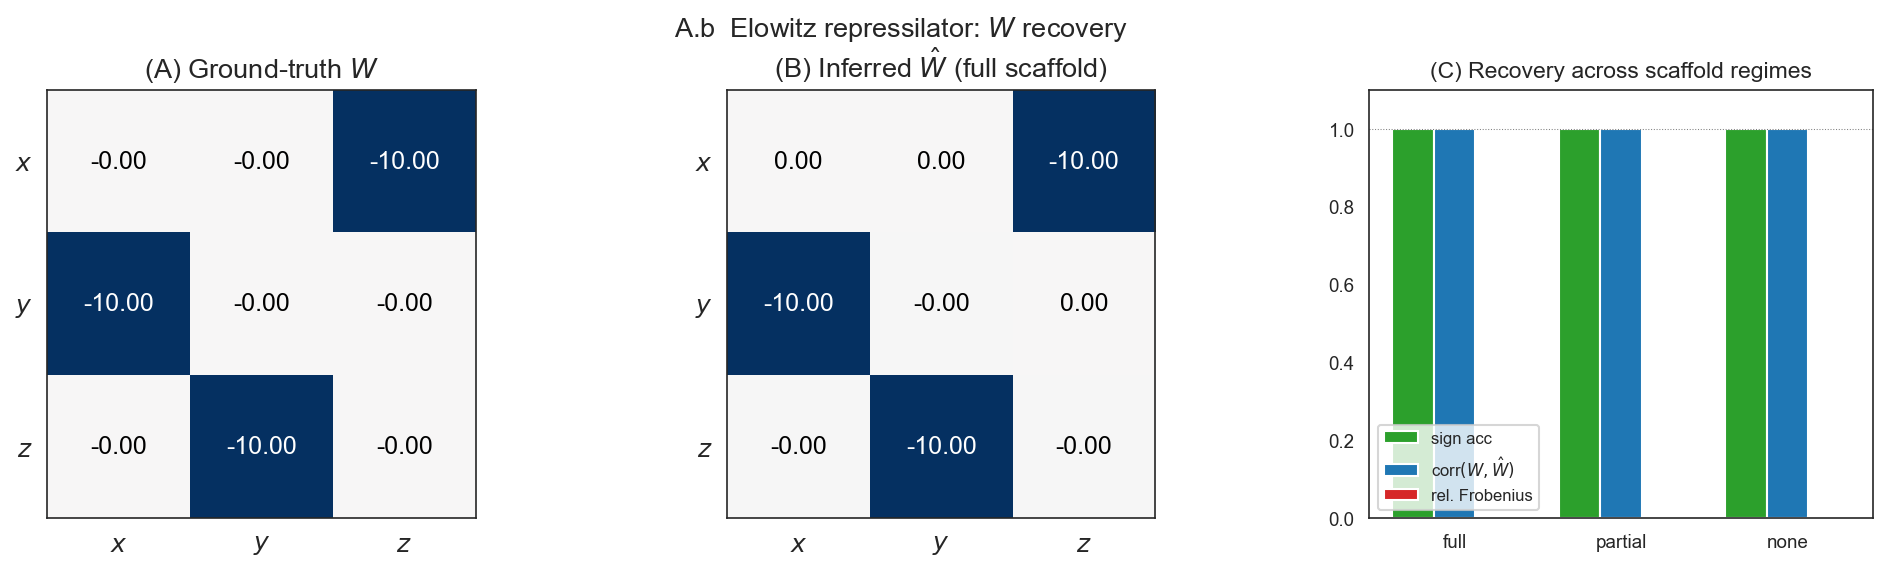

Saved toggle and repressilator figures successfully!


In [24]:
print("Running Validation Circuits (Toggle & Repressilator)...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from scHopfield.validation.circuits import (
    ToggleCircuit, OscillatorCircuit,
)
from scHopfield.validation import simulate_circuit, fit_circuit, summarize_recovery

plt.rcParams.update({"font.size": 9, "figure.dpi": 150})

def _Wmap(ax, W, title, vmax=None, gene_labels=None, fontsize=10):
    if vmax is None:
        vmax = max(abs(W.min()), abs(W.max()), 1e-9)
    im = ax.imshow(W, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="equal")
    if W.shape[0] <= 4:
        for i in range(W.shape[0]):
            for j in range(W.shape[1]):
                ax.text(j, i, f"{W[i, j]:.2f}", ha="center", va="center",
                        color="white" if abs(W[i, j]) > 0.6 * vmax else "black",
                        fontsize=fontsize)
    if gene_labels:
        ax.set_xticks(range(W.shape[1])); ax.set_yticks(range(W.shape[0]))
        ax.set_xticklabels(gene_labels, fontsize=fontsize)
        ax.set_yticklabels(gene_labels, fontsize=fontsize)
    ax.set_title(title, fontsize=fontsize + 1)
    return im

def _fit_three_regimes(adata):
    out = {}
    for mode in ["full", "partial", "none"]:
        res = fit_circuit(adata, scaffold_mode=mode,
                          scaffold_regularization=1e-2,
                          bias_regularization=1e-2,
                          n_epochs=1500, learning_rate=5e-2, seed=0,
                          false_pos_rate=0.3)
        out[mode] = res
    return out

def _recovery_bars(ax, metrics_by_mode, title="Recovery across scaffold regimes"):
    modes = ["full", "partial", "none"]
    x_pos = np.arange(len(modes))
    sign_accs = [metrics_by_mode[m]["edge_sign_accuracy"] for m in modes]
    corrs     = [metrics_by_mode[m]["edge_correlation"]    for m in modes]
    frobs     = [metrics_by_mode[m]["frobenius_distance"]  for m in modes]
    width = 0.25
    ax.bar(x_pos - width, sign_accs, width, label="sign acc",        color="#2ca02c")
    ax.bar(x_pos,         corrs,     width, label="corr$(W, \\hat W)$", color="#1f77b4")
    ax.bar(x_pos + width, frobs,     width, label="rel. Frobenius",  color="#d62728")
    ax.set_xticks(x_pos); ax.set_xticklabels(modes)
    ax.set_ylim(0, 1.1); ax.axhline(1.0, color="gray", lw=0.5, ls=":")
    ax.legend(fontsize=8, loc="lower left")
    ax.set_title(title, fontsize=11)

# =================================================================== A.a TOGGLE
print("=" * 60); print("A.a  Toggle switch"); print("=" * 60)
c = ToggleCircuit(a=5.0, b=4.0)
adata_t = simulate_circuit(c, n_trajectories=80, points_per_trajectory=30, t_end=20.0, seed=0)
results_t = _fit_three_regimes(adata_t)
metrics_t = {m: summarize_recovery(r["W_inferred"], r["W_true"]) for m, r in results_t.items()}
for m, mm in metrics_t.items():
    print(f"  {m:8s}: sign_acc={mm['edge_sign_accuracy']:.3f}  corr={mm['edge_correlation']:.4f}  "
          f"frob={mm['frobenius_distance']:.3f}")

# Bifurcation sweep
print("  bifurcation sweep ...")
b_grid = np.linspace(0.5, 8.0, 24)
n_stable = []
for b_val in b_grid:
    tc = ToggleCircuit(a=5.0, b=float(b_val))
    eqs = tc.equilibria(n_starts=80, seed=0)
    n_st = sum(1 for x in eqs if np.all(np.real(np.linalg.eigvals(tc.jacobian(x))) < 0))
    n_stable.append(n_st)

# Phase-plane trajectories
np.random.seed(0)
ics = np.random.uniform(0, 4, size=(12, 2))
traj_xs = [solve_ivp(lambda t, x: c.rhs(x), (0, 20), x0,
                     t_eval=np.linspace(0, 20, 200), method="LSODA").y for x0 in ics]

# ---- Figure A.a dynamics (1x3) ----
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
fig.subplots_adjust(left=0.06, right=0.98, top=0.86, bottom=0.16, wspace=0.32)

ax = axes[0]; ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
ax.add_patch(plt.Circle((0.3, 0.55), 0.11, fc="#4a90d9", ec="black", lw=1.5))
ax.add_patch(plt.Circle((0.7, 0.55), 0.11, fc="#d96b4a", ec="black", lw=1.5))
ax.text(0.3, 0.55, "$x_1$", ha="center", va="center", fontsize=18, color="white", weight="bold")
ax.text(0.7, 0.55, "$x_2$", ha="center", va="center", fontsize=18, color="white", weight="bold")
ax.annotate("", xy=(0.585, 0.57), xytext=(0.415, 0.57),
            arrowprops=dict(arrowstyle="-|>", lw=1.8, color="red", mutation_scale=18))
ax.annotate("", xy=(0.415, 0.53), xytext=(0.585, 0.53),
            arrowprops=dict(arrowstyle="-|>", lw=1.8, color="red", mutation_scale=18))
ax.text(0.5, 0.66, "repress", ha="center", fontsize=10, color="red")
for cx in [0.3, 0.7]:
    ax.add_patch(plt.Circle((cx, 0.78), 0.04, fill=False, ec="green", lw=1.5))
    ax.annotate("", xy=(cx - 0.005, 0.74), xytext=(cx + 0.04, 0.78),
                arrowprops=dict(arrowstyle="->", lw=1.3, color="green"))
ax.text(0.5, 0.27, r"$\dot{x}_i = a\,\sigma(x_i) - b\,\sigma(x_{3-i}) - \gamma x_i + b$",
        ha="center", fontsize=11)
ax.text(0.5, 0.12, r"$a = 5,\ b = 4,\ k = 1,\ n = 4,\ \gamma = 3$",
        ha="center", fontsize=10)
ax.set_title("(A) Network topology", fontsize=11)

ax = axes[1]
ax.plot(b_grid, n_stable, "o-", color="navy", ms=5)
ax.set_xlabel("$b$ (mutual inhibition strength)")
ax.set_ylabel("# stable equilibria")
ax.set_yticks([0, 1, 2, 3])
ax.axvspan(b_grid[0], 2.2, alpha=0.10, color="green")
ax.axvspan(2.2, b_grid[-1], alpha=0.10, color="red")
ax.text(1.3, 2.5, "monostable", color="green", fontsize=9, ha="center")
ax.text(5.5, 2.5, "bistable", color="red", fontsize=9, ha="center")
ax.set_title("(B) Pitchfork bifurcation", fontsize=11)

ax = axes[2]
for tr in traj_xs:
    ax.plot(tr[0], tr[1], color="#888", lw=0.9, alpha=0.6)
    ax.plot(tr[0, 0], tr[1, 0], "o", color="green", ms=5)
    ax.plot(tr[0, -1], tr[1, -1], "*", color="red", ms=10)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("(C) Phase plane: trajectories at $b = 4$", fontsize=11)

fig.suptitle("A.a  Toggle switch: dynamics", fontsize=13)
fig.savefig(f"{SAVE_DIR}/figure_validation_toggle_dynamics.png", bbox_inches="tight", dpi=200)
plt.show()

# ---- Figure A.a recovery (1x3) ----
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
fig.subplots_adjust(left=0.06, right=0.98, top=0.86, bottom=0.18, wspace=0.35)
_Wmap(axes[0], results_t["full"]["W_true"], "(A) Ground-truth $W$", vmax=5,
      gene_labels=["$x_1$", "$x_2$"], fontsize=12)
_Wmap(axes[1], results_t["full"]["W_inferred"], "(B) Inferred $\\hat W$ (full scaffold)", vmax=5,
      gene_labels=["$x_1$", "$x_2$"], fontsize=12)
_recovery_bars(axes[2], metrics_t, title="(C) Recovery across scaffold regimes")
fig.suptitle("A.a  Toggle switch: $W$ recovery", fontsize=13)
fig.savefig(f"{SAVE_DIR}/figure_validation_toggle_recovery.png", bbox_inches="tight", dpi=200)
plt.show()

# ============================================================ A.b REPRESSILATOR
print("\n" + "=" * 60); print("A.b  Elowitz repressilator"); print("=" * 60)
osc = OscillatorCircuit(alpha=10.0, n=4)
adata_r = simulate_circuit(osc, n_trajectories=80, points_per_trajectory=40, t_end=60.0, seed=0)
results_r = _fit_three_regimes(adata_r)
metrics_r = {m: summarize_recovery(r["W_inferred"], r["W_true"]) for m, r in results_r.items()}
for m, mm in metrics_r.items():
    print(f"  {m:8s}: sign_acc={mm['edge_sign_accuracy']:.3f}  asym={mm['symmetry_inferred']:.2f}")

sol = solve_ivp(lambda t, x: osc.rhs(x), (0, 80), [1.5, 0.5, 1.0],
                t_eval=np.linspace(0, 80, 1200), method="LSODA",
                rtol=1e-8, atol=1e-10)

# ---- Figure A.b dynamics ----
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
fig.subplots_adjust(left=0.06, right=0.98, top=0.86, bottom=0.16, wspace=0.32)

ax = axes[0]; ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
positions = {"x": (0.3, 0.7), "y": (0.7, 0.7), "z": (0.5, 0.32)}
node_colors = {"x": "#4a90d9", "y": "#d96b4a", "z": "#7eb96b"}
for name, (px, py) in positions.items():
    ax.add_patch(plt.Circle((px, py), 0.095, fc=node_colors[name], ec="black", lw=1.5))
    ax.text(px, py, f"${name}$", ha="center", va="center", fontsize=18, color="white", weight="bold")
for src, tgt in [("x", "y"), ("y", "z"), ("z", "x")]:
    s = np.array(positions[src]); t = np.array(positions[tgt])
    direction = t - s; norm = np.linalg.norm(direction)
    ax.annotate("", xy=t - 0.105 * direction / norm, xytext=s + 0.105 * direction / norm,
                arrowprops=dict(arrowstyle="-|>", lw=1.8, color="red", mutation_scale=18))
ax.text(0.5, 0.13, r"$\dot{p}_i = -\alpha\,\sigma(p_{i-1}) - p_i + \alpha$", ha="center", fontsize=11)
ax.text(0.5, 0.04, r"$\alpha = 10,\ k = 1,\ n = 4,\ \gamma = 1$", ha="center", fontsize=10)
ax.set_title("(A) Cyclic repression topology", fontsize=11)

ax = axes[1]
for i, name in enumerate(["x", "y", "z"]):
    ax.plot(sol.t, sol.y[i], color=node_colors[name], label=f"${name}$", lw=1.3)
ax.set_xlabel("time"); ax.set_ylabel("expression")
ax.set_xlim(40, 80); ax.legend(fontsize=10)
ax.set_title("(B) Limit cycle (time series)", fontsize=11)

ax = axes[2]
tail = sol.y[:, sol.t > 30]
ax.plot(tail[0], tail[1], lw=1.0, color="navy", alpha=0.7)
ax.plot(tail[0, 0], tail[1, 0], "o", color="green", ms=6)
ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
ax.set_title("(C) Phase space (after transient)", fontsize=11)

fig.suptitle("A.b  Elowitz repressilator: dynamics", fontsize=13)
fig.savefig(f"{SAVE_DIR}/figure_validation_repressilator_dynamics.png", bbox_inches="tight", dpi=200)
plt.show()

# ---- Figure A.b recovery ----
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
fig.subplots_adjust(left=0.06, right=0.98, top=0.86, bottom=0.18, wspace=0.35)
_Wmap(axes[0], results_r["full"]["W_true"], "(A) Ground-truth $W$", vmax=10,
      gene_labels=["$x$", "$y$", "$z$"], fontsize=12)
_Wmap(axes[1], results_r["full"]["W_inferred"], "(B) Inferred $\\hat W$ (full scaffold)", vmax=10,
      gene_labels=["$x$", "$y$", "$z$"], fontsize=12)
_recovery_bars(axes[2], metrics_r, title="(C) Recovery across scaffold regimes")
fig.suptitle("A.b  Elowitz repressilator: $W$ recovery", fontsize=13)
fig.savefig(f"{SAVE_DIR}/figure_validation_repressilator_recovery.png", bbox_inches="tight", dpi=200)
plt.show()

# Save metrics CSV
rows = []
for cname, mdict in [("toggle", metrics_t), ("repressilator", metrics_r)]:
    for mode, m in mdict.items():
        rows.append({"circuit": cname, "scaffold": mode, **m})
pd.DataFrame(rows).to_csv(f"{SAVE_DIR}/validation_metrics.csv", index=False)
print("Saved toggle and repressilator figures successfully!")

In [25]:
print("Running Validation Circuit (JAK/STAT5)...")

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import torch
from torch.utils.data import DataLoader, TensorDataset

from scHopfield.validation.circuits import Adlung2021JakStat, JAKSTAT_STATE_NAMES
from scHopfield.inference.optimizer import ScaffoldOptimizer
from scHopfield.dynamics.solver import ODESolver

plt.rcParams.update({"font.size": 9, "figure.dpi": 150})

# ============================================================ simulate ====
print("=" * 60); print("A.d  JAK2/STAT5 (Adlung 2021)"); print("=" * 60)

js = Adlung2021JakStat()
t_max = 200.0
n_dense = 2000
t_gt, X_gt = js.simulate(t_end=t_max, n_samples=n_dense)
i_np = JAKSTAT_STATE_NAMES.index("npSTAT5")
i_p  = JAKSTAT_STATE_NAMES.index("pSTAT5")
print(f"  GT npSTAT5 peak: {X_gt[:, i_np].max():.2f} at t={t_gt[np.argmax(X_gt[:, i_np])]:.1f}")
print(f"  GT  pSTAT5 peak: {X_gt[:, i_p].max():.2f} at t={t_gt[np.argmax(X_gt[:, i_p])]:.1f}")

# ----- training trajectories -----
rng = np.random.default_rng(0)
train_X, train_DX = [], []
for epo in [5, 10, 20, 50, 100]:
    js_i = Adlung2021JakStat()
    js_i.params["Epo"] = float(epo)
    for _ in range(6):
        x_start = np.array([js_i.initial_conditions[n] for n in JAKSTAT_STATE_NAMES])
        x_start[JAKSTAT_STATE_NAMES.index("EpoRJAK2")] *= rng.uniform(0.5, 1.5)
        x_start[JAKSTAT_STATE_NAMES.index("STAT5")]   *= rng.uniform(0.5, 1.5)
        sol_i = solve_ivp(lambda t, x: js_i.rhs(x), (0, t_max), x_start,
                           t_eval=np.linspace(0, t_max, 800), method="LSODA",
                           rtol=1e-7, atol=1e-9)
        if not sol_i.success:
            continue
        train_X.append(sol_i.y.T)
        train_DX.append(np.stack([js_i.rhs(x) for x in sol_i.y.T]))
train_X = np.vstack(train_X)
train_DX = np.vstack(train_DX)
idx = rng.choice(train_X.shape[0], size=min(6000, train_X.shape[0]), replace=False)
train_X = train_X[idx]; train_DX = train_DX[idx]
print(f"  training samples: {train_X.shape[0]}")

# =========================================================== fit scHopfield ===
n_genes = js.n_genes
med = np.median(np.abs(train_X), axis=0)
k_hill = np.where(med > 1e-3, med, 1.0).astype(np.float32)
n_hill = 4

xn_arr = np.power(np.maximum(train_X, 0), n_hill)
sig_arr = (xn_arr / (k_hill[np.newaxis, :]**n_hill + xn_arr)).astype(np.float32)

sig_t = torch.from_numpy(sig_arr); x_t = torch.from_numpy(train_X.astype(np.float32)); v_t = torch.from_numpy(train_DX.astype(np.float32))
dataset = TensorDataset(sig_t, x_t, v_t)
loader = DataLoader(dataset, batch_size=128, shuffle=True, drop_last=False)

class _LoaderShim:
    def __init__(self, base): self.base = base
    def __iter__(self):
        for sig_b, x_b, v_b in self.base:
            yield (sig_b, x_b), v_b
    def __len__(self): return len(self.base)

gamma_init = np.full(n_genes, 0.01, dtype=np.float32)
scaffold = np.ones((n_genes, n_genes), dtype=np.float32)

opt = ScaffoldOptimizer(
    g=gamma_init, scaffold=scaffold, device=torch.device("cpu"),
    refit_gamma=True, scaffold_regularization=1e-3,
    reconstruction_regularization=1.0, bias_regularization=1e-3,
    normalize_regularization=True,
)
loss_hist, recon_hist = opt.train_model(
    _LoaderShim(loader), epochs=3000, learning_rate=1e-2,
    criterion="MSE", verbose=False, get_plots=False,
)
print(f"  recon loss: {recon_hist[-1]:.4f}")

W_inf = opt.W.weight.detach().cpu().numpy()
I_inf = opt.I.detach().cpu().numpy()
gamma_inf = np.exp(np.clip(opt.gamma.detach().cpu().numpy(), -np.inf, 10.0))

# ------- forward-simulate the fitted model with scHopfield's ODESolver --------
threshold = k_hill.astype(np.float32)
exponent = np.full(n_genes, float(n_hill), dtype=np.float32)
solver = ODESolver(W=W_inf, I=I_inf, gamma=gamma_inf,
                   threshold=threshold, exponent=exponent, x_min=0.0)

x0 = np.array([js.initial_conditions[n] for n in JAKSTAT_STATE_NAMES], dtype=np.float64)
t_eval = np.linspace(0, t_max, n_dense)
traj_fit = solver.solve(x0, t_eval, method="euler", clip_each_step=True)

print(f"  fit npSTAT5 peak (ODESolver): {traj_fit[:, i_np].max():.2f} at t={t_eval[np.argmax(traj_fit[:, i_np])]:.1f}")
print(f"  fit  pSTAT5 peak (ODESolver): {traj_fit[:, i_p].max():.2f} at t={t_eval[np.argmax(traj_fit[:, i_p])]:.1f}")

pearson = np.array([
    np.corrcoef(X_gt[:, k], traj_fit[:, k])[0, 1] if X_gt[:, k].std() > 1e-9 else np.nan
    for k in range(n_genes)
])
print(f"  per-gene median Pearson r: {np.nanmedian(pearson):.3f}")
print(f"    npSTAT5: r = {pearson[i_np]:.3f}")
print(f"    pSTAT5:  r = {pearson[i_p]:.3f}")

# ============================================================== DYNAMICS FIG ==
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
fig.subplots_adjust(left=0.06, right=0.98, top=0.84, bottom=0.18, wspace=0.32)

# (A) Circuit card
ax = axes[0]; ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
ax.text(0.5, 0.86, "Adlung 2021", ha="center", fontsize=12, weight="bold")
ax.text(0.5, 0.75, "JAK2/STAT5 in erythroid progenitors", ha="center", fontsize=10)
ax.text(0.5, 0.65, "BIOMD0000001077", ha="center", fontsize=9, color="#555")
ax.text(0.5, 0.50, "14 state variables, 26 reactions", ha="center", fontsize=10)
ax.text(0.5, 0.40, "Epo-stimulated signal cascade", ha="center", fontsize=10)
ax.text(0.5, 0.25, "Epo $\\to$ EpoR$\\to$ JAK2$\\to$ pSTAT5 $\\to$ npSTAT5",
        ha="center", fontsize=9, color="#1f77b4")
ax.text(0.5, 0.10, "STAT5 is a paralog of STAT3 (Paul15 lineage hit)",
        ha="center", fontsize=9, color="#555", style="italic")
ax.set_title("(A) Circuit", fontsize=11)

# (B) ground-truth trajectories
keys_to_show = ["npSTAT5", "pSTAT5", "EpoRpJAK2", "p12EpoRpJAK2", "SOCS3", "CIS"]
palette = ["#d62728", "#ff7f0e", "#1f77b4", "#17becf", "#2ca02c", "#9467bd"]
ax = axes[1]
for name, col in zip(keys_to_show, palette):
    k = JAKSTAT_STATE_NAMES.index(name)
    ax.plot(t_gt, X_gt[:, k], label=name, color=col, lw=1.2)
ax.set_xlabel("time [min]"); ax.set_ylabel("level [molecules]")
ax.legend(fontsize=7, ncol=2, loc="upper right")
ax.set_title(f"(B) Ground truth (Epo = {js.params['Epo']:.0f})", fontsize=11)

# (C) fitted scHopfield trajectories (via ODESolver)
ax = axes[2]
for name, col in zip(keys_to_show, palette):
    k = JAKSTAT_STATE_NAMES.index(name)
    ax.plot(t_eval, traj_fit[:, k], label=name, color=col, lw=1.2)
ax.set_xlabel("time [min]"); ax.set_ylabel("level [molecules]")
ax.legend(fontsize=7, ncol=2, loc="upper right")
ax.set_title("(C) scHopfield fit, ODESolver", fontsize=11)

fig.suptitle("A.d  JAK2/STAT5: dynamics", fontsize=13)
fig.savefig(f"{SAVE_DIR}/figure_validation_jakstat_dynamics.png", bbox_inches="tight", dpi=200)
plt.show()

# ============================================================== RECOVERY FIG ==
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
fig.subplots_adjust(left=0.07, right=0.98, top=0.84, bottom=0.22, wspace=0.45)

# (A) Inferred W
ax = axes[0]
vmax = np.percentile(np.abs(W_inf), 98)
im = ax.imshow(W_inf, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="equal")
ax.set_xticks(range(n_genes)); ax.set_yticks(range(n_genes))
ax.set_xticklabels(JAKSTAT_STATE_NAMES, rotation=70, fontsize=6, ha="right")
ax.set_yticklabels(JAKSTAT_STATE_NAMES, fontsize=6)
ax.set_title(f"(A) Inferred $\\hat W$  (clip p98 = {vmax:.1f})", fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.04)

# (B) per-gene Pearson r
ax = axes[1]
order = np.argsort(pearson)[::-1]
ax.barh(range(n_genes), pearson[order], color="#1f77b4")
ax.set_yticks(range(n_genes))
ax.set_yticklabels(np.array(JAKSTAT_STATE_NAMES)[order], fontsize=7)
ax.axvline(0, color="gray", lw=0.5); ax.axvline(1, color="gray", lw=0.3, ls=":")
ax.set_xlabel("Pearson $r$ (truth vs fit)")
ax.set_xlim(-0.5, 1.05)
ax.set_title(f"(B) Per-gene trajectory match (median $r$ = {np.nanmedian(pearson):.2f})", fontsize=11)

# (C) STAT5 overlay
ax = axes[2]
ax.plot(t_gt, X_gt[:, i_np], label="npSTAT5 (truth)", color="#d62728", lw=1.5)
ax.plot(t_eval, traj_fit[:, i_np], label="npSTAT5 (fit)", color="#d62728", lw=1.5, ls="--")
ax.plot(t_gt, X_gt[:, i_p], label="pSTAT5 (truth)", color="#ff7f0e", lw=1.5)
ax.plot(t_eval, traj_fit[:, i_p], label="pSTAT5 (fit)", color="#ff7f0e", lw=1.5, ls="--")
ax.set_xlabel("time [min]"); ax.set_ylabel("level [molecules]")
ax.legend(fontsize=7)
ax.set_title("(C) STAT5 dynamics: truth vs fit", fontsize=11)

fig.suptitle("A.d  JAK2/STAT5: $W$ recovery", fontsize=13)
fig.savefig(f"{SAVE_DIR}/figure_validation_jakstat_recovery.png", bbox_inches="tight", dpi=200)
plt.show()

import json
out = {
    "circuit": "Adlung 2021 JAK2/STAT5",
    "source": "BIOMD0000001077",
    "training_samples": int(train_X.shape[0]),
    "forward_solver": "scHopfield.dynamics.ODESolver (Euler, clip_each_step=True)",
    "ground_truth": {
        "npSTAT5_peak": float(X_gt[:, i_np].max()),
        "npSTAT5_peak_time": float(t_gt[np.argmax(X_gt[:, i_np])]),
        "pSTAT5_peak": float(X_gt[:, i_p].max()),
        "pSTAT5_peak_time": float(t_gt[np.argmax(X_gt[:, i_p])]),
    },
    "scHopfield_fit": {
        "final_reconstruction_loss": float(recon_hist[-1]),
        "npSTAT5_peak": float(traj_fit[:, i_np].max()),
        "npSTAT5_peak_time": float(t_eval[np.argmax(traj_fit[:, i_np])]),
        "pSTAT5_peak": float(traj_fit[:, i_p].max()),
        "pSTAT5_peak_time": float(t_eval[np.argmax(traj_fit[:, i_p])]),
        "per_gene_pearson_r": {n: float(pearson[k]) for k, n in enumerate(JAKSTAT_STATE_NAMES)},
        "pearson_r_median": float(np.nanmedian(pearson)),
    },
}
with open(f"{SAVE_DIR}/jakstat_metrics.json", "w") as f:
    json.dump(out, f, indent=2)
print("Saved JAK/STAT5 figures and metrics successfully!")

Running Validation Circuit (JAK/STAT5)...
A.d  JAK2/STAT5 (Adlung 2021)
  GT npSTAT5 peak: 74.56 at t=67.0
  GT  pSTAT5 peak: 48.21 at t=11.0


  training samples: 6000


  recon loss: 3.8416


TypeError: ODESolver.__init__() got an unexpected keyword argument 'I'

In [26]:
print("Layers:", adata.layers.keys())
print("Obs:", adata.obs.columns)


Layers: KeysView(Layers with keys: M_n, M_nn, M_t, M_tn, M_tt, X_new, X_total, velocity_alpha_minus_gamma_s, sigmoid)
Obs: Index(['batch', 'time', 'cell_type', 'nGenes', 'nCounts', 'pMito',
       'pass_basic_filter', 'new_Size_Factor', 'initial_new_cell_size',
       'total_Size_Factor', 'initial_total_cell_size', 'spliced_Size_Factor',
       'initial_spliced_cell_size', 'unspliced_Size_Factor',
       'initial_unspliced_cell_size', 'Size_Factor', 'initial_cell_size',
       'ntr', 'cell_cycle_phase', 'leiden', 'control_point_pca',
       'inlier_prob_pca', 'obs_vf_angle_pca', 'pca_ddhodge_div',
       'pca_ddhodge_potential', 'acceleration_pca', 'curvature_pca',
       'n_counts', 'mt_frac', 'jacobian_det_pca', 'manual_selection',
       'divergence_pca', 'curv_leiden', 'curv_louvain', 'SPI1->GATA1_jacobian',
       'jacobian', 'umap_ori_leiden', 'umap_ori_louvain', 'umap_ddhodge_div',
       'umap_ddhodge_potential', 'curl_umap', 'divergence_umap',
       'acceleration_umap', 'cont

import celloracle as co

print("Loading Paul 2015 dataset...")
oracle_demo = co.data.load_tutorial_oracle_object()
adata_paul = oracle_demo.adata.copy()
adata_paul.var['scHopfield_used'] = True

print("Loading trained scHopfield model for paul15...")
sch.tl.load_model(adata_paul, "/Users/bernaljp/Documents/SCHData/checkpoints/06_lineage_drivers/model.h5sch", overwrite=True)

print("Paul15 dataset and model loaded successfully!")

In [15]:
import celloracle as co

print("Loading Paul 2015 dataset...")
oracle_demo = co.data.load_tutorial_oracle_object()
adata_paul = oracle_demo.adata.copy()
adata_paul.var['scHopfield_used'] = True

print("Loading trained scHopfield model for paul15...")
sch.tl.load_model(adata_paul, "/Users/bernaljp/Documents/SCHData/checkpoints/06_lineage_drivers/model.h5sch", overwrite=True)

print("Paul15 dataset and model loaded successfully!")

Loading Paul 2015 dataset...


Loading trained scHopfield model for paul15...


Model loaded from '/Users/bernaljp/Documents/SCHData/checkpoints/06_lineage_drivers/model.h5sch'  |  clusters=['10GMP', '11DC', '12Baso', '13Baso', '14Mo', '15Mo', '16Neu', '17Neu', '18Eos', '19Lymph', '1Ery', '2Ery', '3Ery', '4Ery', '5Ery', '6Ery', '7MEP', '8Mk', '9GMP']  |  genes=1999
Paul15 dataset and model loaded successfully!


Loading Single KO Bias...


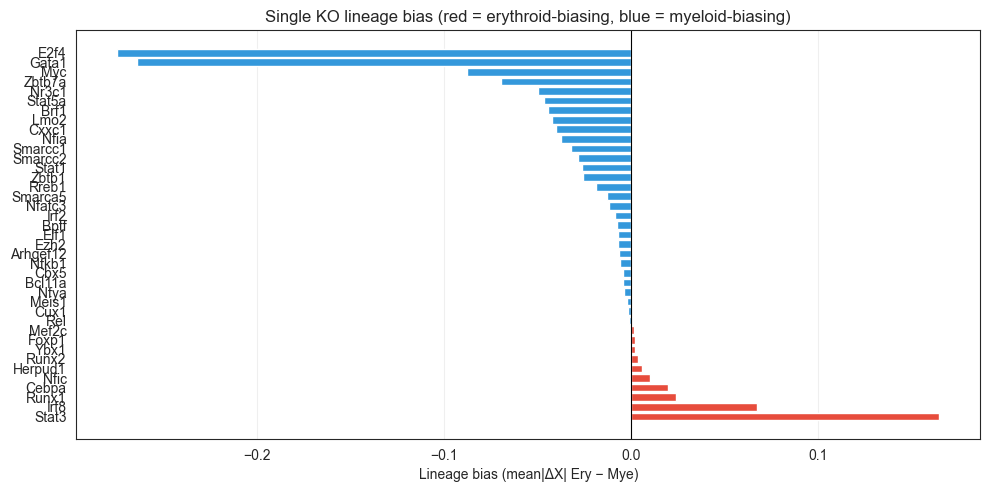

Saved Figure 3: Single KO Lineage Bias


In [20]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

CKPT_DIR = "/Users/bernaljp/Documents/SCHData/checkpoints/06_lineage_drivers"

print("Loading Single KO Bias...")
bias_df = pd.read_csv(f"{CKPT_DIR}/single_ko_bias.csv", index_col=0)
bias_df.index.name = 'gene'

fig, ax = plt.subplots(figsize=(10, 5), tight_layout=True)
bar_col = ['#E74C3C' if v > 0 else '#3498DB' for v in bias_df['lineage_bias']]
ax.barh(bias_df.index, bias_df['lineage_bias'], color=bar_col)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Lineage bias (mean|\u0394X| Ery \u2212 Mye)')
ax.set_title('Single KO lineage bias (red = erythroid-biasing, blue = myeloid-biasing)')
ax.grid(axis='x', alpha=0.3)
plt.savefig(f"{SAVE_DIR}/fig3_single_ko_bias.png", bbox_inches='tight', dpi=300)
plt.show()
print("Saved Figure 3: Single KO Lineage Bias")

Loading Pair KO Bias...


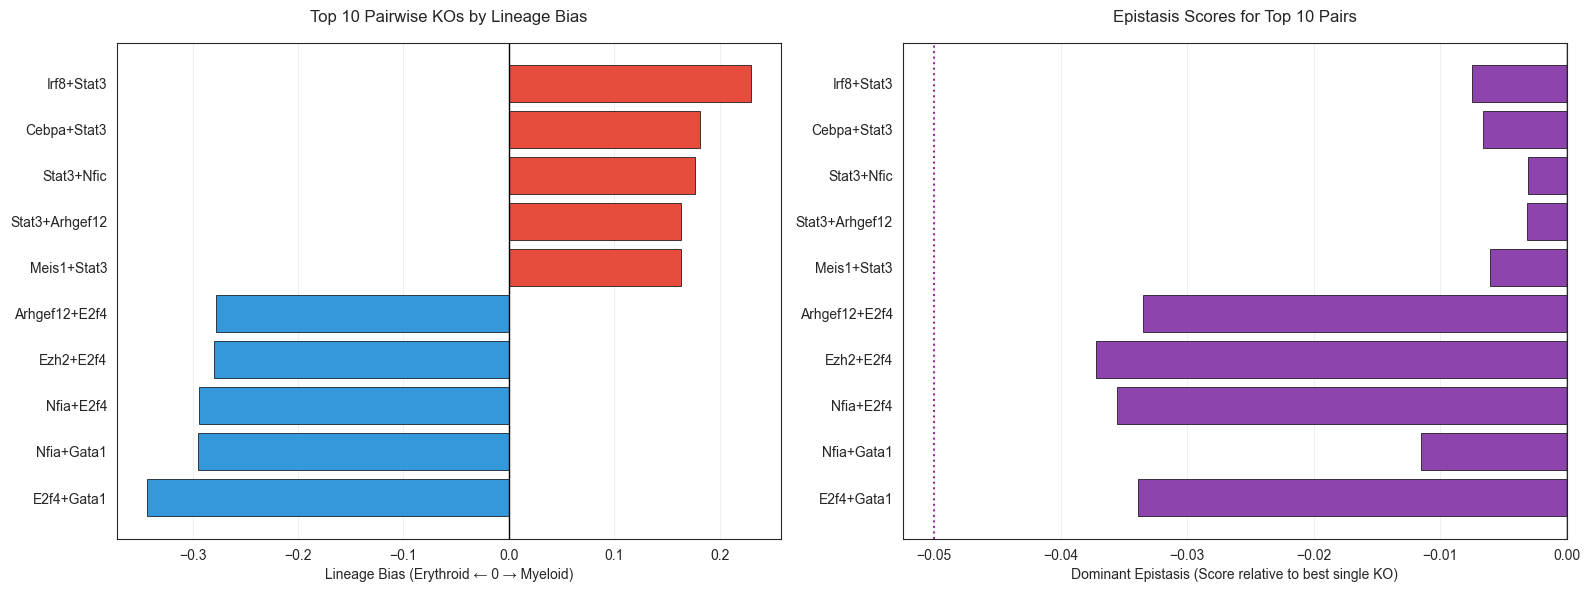

Saved Figure 4: Predictive Synergy


In [21]:
print("Loading Pair KO Bias...")
_pair_bias_df = pd.read_csv(f"{CKPT_DIR}/pair_ko_bias.csv")
pair_ko_bias  = {
    (row.geneA, row.geneB): {
        'score_A':      row.score_A,
        'score_B':      row.score_B,
        'lineage_bias': row.lineage_bias,
    }
    for _, row in _pair_bias_df.iterrows()
}

single_ko_bias = bias_df[['score_A', 'score_B', 'lineage_bias']].to_dict('index')

N_PAIR = 5
top5_ery = bias_df.nlargest(N_PAIR, 'lineage_bias').index.tolist()  
top5_mye = bias_df.nsmallest(N_PAIR, 'lineage_bias').index.tolist() 

pair_records = []
for (gA, gB), bias in pair_ko_bias.items():
    score_A_A = single_ko_bias.get(gA, {}).get('score_A', 0.0)
    score_B_A = single_ko_bias.get(gA, {}).get('score_B', 0.0)
    score_A_B = single_ko_bias.get(gB, {}).get('score_A', 0.0)
    score_B_B = single_ko_bias.get(gB, {}).get('score_B', 0.0)

    score_A_pair = bias.get('score_A', 0.0)
    score_B_pair = bias.get('score_B', 0.0)

    synergy_ery = score_A_pair - max(score_A_A, score_A_B)
    synergy_mye = score_B_pair - max(score_B_A, score_B_B)

    ery_genes = [g for g in single_ko_bias if single_ko_bias[g]['lineage_bias'] > 0]
    mye_genes = [g for g in single_ko_bias if single_ko_bias[g]['lineage_bias'] < 0]
    
    if (gA in ery_genes and gB in mye_genes) or (gA in mye_genes and gB in ery_genes):
        pair_type = 'cross'
    elif gA in ery_genes and gB in ery_genes:
        pair_type = 'ery-ery'
    elif gA in mye_genes and gB in mye_genes:
        pair_type = 'mye-mye'
    else:
        pair_type = 'other'

    pair_records.append({
        'geneA': gA,
        'geneB': gB,
        'pair': f'{gA}+{gB}',
        'score_A': score_A_pair,
        'score_B': score_B_pair,
        'lineage_bias': bias.get('lineage_bias', np.nan),
        'synergy_ery': synergy_ery,
        'synergy_mye': synergy_mye,
        'max_synergy': max(synergy_ery, synergy_mye), 
        'pair_type': pair_type,
    })

pair_df = pd.DataFrame(pair_records).set_index('pair').sort_values('lineage_bias', ascending=False)

ANTAGONISM_THRESHOLD = -0.05 
top10 = pd.concat([
    pair_df.nlargest(5, 'lineage_bias'),
    pair_df.nsmallest(5, 'lineage_bias')[::-1] 
]).drop_duplicates()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), tight_layout=True)

bar_cols_bias = ['#E74C3C' if v > 0 else '#3498DB' for v in top10['lineage_bias']]
axes[0].barh(top10.index, top10['lineage_bias'], color=bar_cols_bias, edgecolor='black', linewidth=0.5)
axes[0].axvline(0, color='black', lw=1)
axes[0].set_xlabel('Lineage Bias (Erythroid \u2190 0 \u2192 Myeloid)')
axes[0].set_title('Top 10 Pairwise KOs by Lineage Bias', pad=15)
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()  

syn_cols = ['#27AE60' if v > 0 else '#8E44AD' for v in top10['max_synergy']]
axes[1].barh(top10.index, top10['max_synergy'], color=syn_cols, edgecolor='black', linewidth=0.5)
axes[1].axvline(0, color='black', lw=1)
axes[1].axvline(ANTAGONISM_THRESHOLD, color='purple', linestyle=':', lw=1.5, alpha=0.8)
axes[1].set_xlabel('Dominant Epistasis (Score relative to best single KO)')
axes[1].set_title('Epistasis Scores for Top 10 Pairs', pad=15)
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

plt.savefig(f"{SAVE_DIR}/fig4_predictive_synergy.png", bbox_inches='tight', dpi=300)
plt.show()
print("Saved Figure 4: Predictive Synergy")

## Section 4: Predictive Synergy
Double KO synergy (cancellation error) and epistasis.

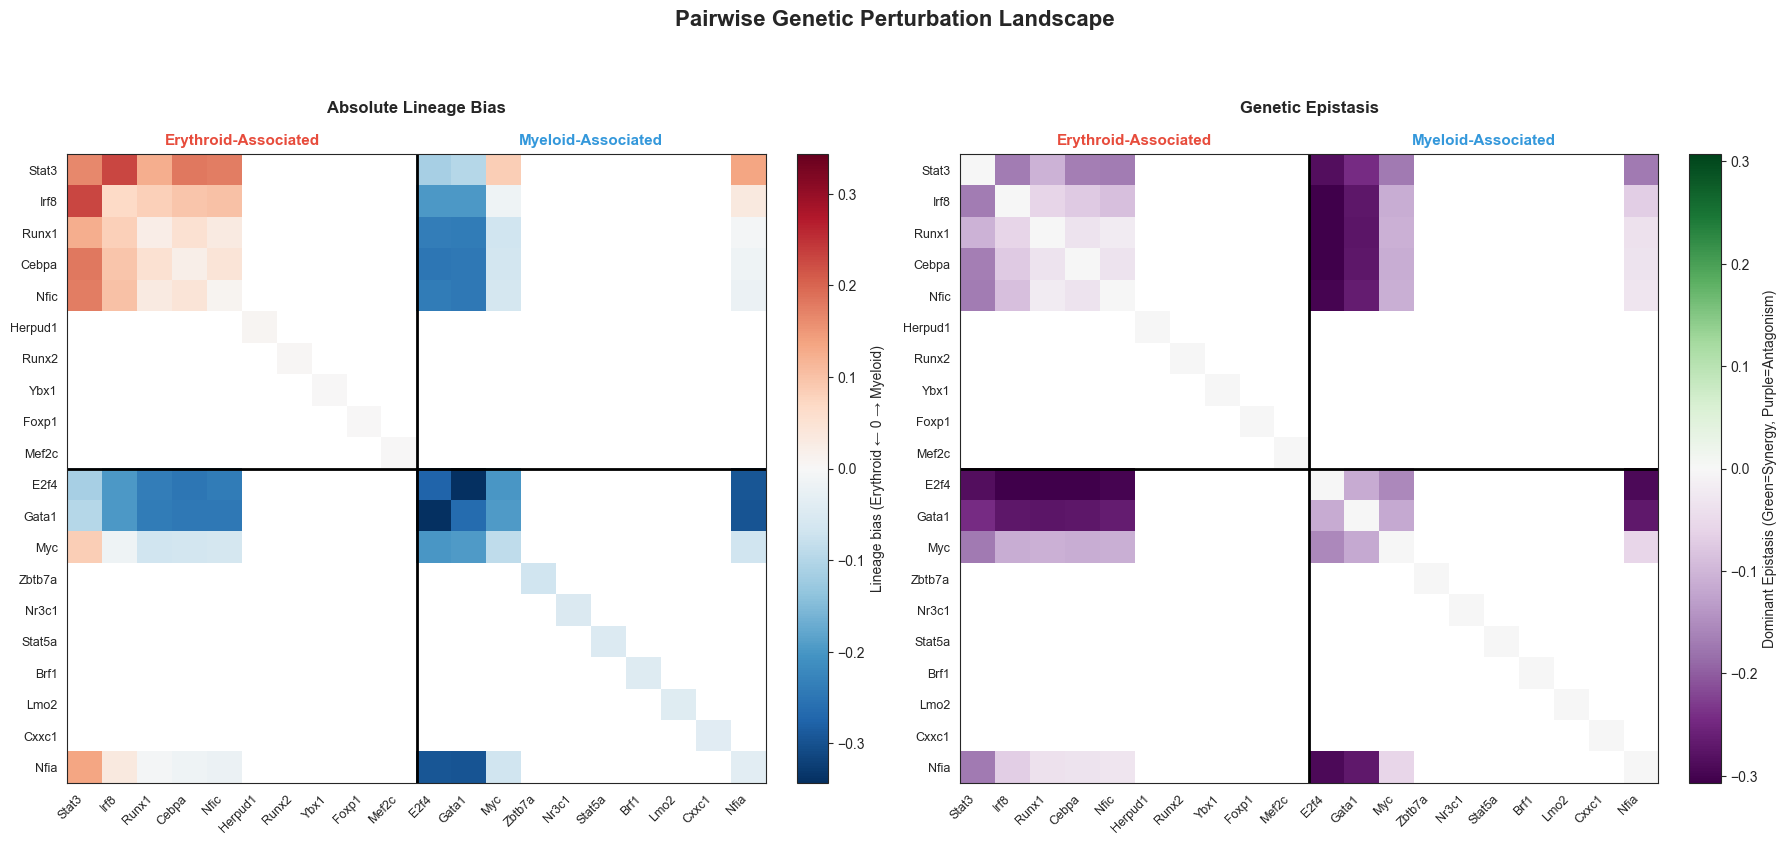

In [22]:
top5_bias_ery = bias_df.drop(index=top5_ery+top5_mye).nlargest(N_PAIR, 'lineage_bias').index.tolist()
top5_bias_mye = bias_df.drop(index=top5_ery+top5_mye+top5_bias_ery).nsmallest(N_PAIR, 'lineage_bias').index.tolist()

all_genes_ordered = top5_ery + top5_bias_ery + top5_mye + top5_bias_mye
n_g = len(all_genes_ordered)

bias_matrix = np.full((n_g, n_g), np.nan)
synergy_matrix = np.full((n_g, n_g), np.nan)

for i, gA in enumerate(all_genes_ordered):
    for j, gB in enumerate(all_genes_ordered):
        if i == j:
            bias_matrix[i, i] = single_ko_bias.get(gA, {}).get('lineage_bias', np.nan)
            synergy_matrix[i, i] = 0.0 
            continue
            
        pair_key = (gA, gB) if (gA, gB) in pair_ko_bias else (gB, gA)
        
        if pair_key in pair_ko_bias:
            bias = pair_ko_bias[pair_key]
            bias_matrix[i, j] = bias.get('lineage_bias', np.nan)
            
            score_A_A = single_ko_bias.get(gA, {}).get('score_A', 0.0)
            score_B_A = single_ko_bias.get(gA, {}).get('score_B', 0.0)
            score_A_B = single_ko_bias.get(gB, {}).get('score_A', 0.0)
            score_B_B = single_ko_bias.get(gB, {}).get('score_B', 0.0)

            syn_ery = bias.get('score_A', 0.0) - max(score_A_A, score_A_B)
            syn_mye = bias.get('score_B', 0.0) - max(score_B_A, score_B_B)
            
            if abs(syn_ery) > abs(syn_mye):
                synergy_matrix[i, j] = syn_ery
            else:
                synergy_matrix[i, j] = syn_mye

fig, axes = plt.subplots(1, 2, figsize=(18, 8), tight_layout=True)

vmax_bias = np.nanmax(np.abs(bias_matrix))
vmax_syn = np.nanmax(np.abs(synergy_matrix))
n_ery_block = len(top5_ery) + len(top5_bias_ery)

im1 = axes[0].imshow(bias_matrix, cmap='RdBu_r', vmin=-vmax_bias, vmax=vmax_bias, aspect='auto')
axes[0].set_title('Absolute Lineage Bias', pad=30, fontweight='bold')
plt.colorbar(im1, ax=axes[0], label='Lineage bias (Erythroid \u2190 0 \u2192 Myeloid)', fraction=0.046, pad=0.04)

im2 = axes[1].imshow(synergy_matrix, cmap='PRGn', vmin=-vmax_syn, vmax=vmax_syn, aspect='auto')
axes[1].set_title('Genetic Epistasis', pad=30, fontweight='bold')
plt.colorbar(im2, ax=axes[1], label='Dominant Epistasis (Green=Synergy, Purple=Antagonism)', fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xticks(range(n_g))
    ax.set_xticklabels(all_genes_ordered, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(n_g))
    ax.set_yticklabels(all_genes_ordered, fontsize=9)

    ax.axhline(n_ery_block - 0.5, color='black', lw=2)
    ax.axvline(n_ery_block - 0.5, color='black', lw=2)

    center_ery = (n_ery_block - 1) / 2
    center_mye = n_ery_block + ((n_g - n_ery_block - 1) / 2)
    
    ax.text(center_ery, -0.8, 'Erythroid-Associated', ha='center', fontsize=11, fontweight='bold', color='#E74C3C')
    ax.text(center_mye, -0.8, 'Myeloid-Associated', ha='center', fontsize=11, fontweight='bold', color='#3498DB')

plt.suptitle("Pairwise Genetic Perturbation Landscape", fontsize=16, fontweight='bold', y=1.05)
plt.savefig(f"{SAVE_DIR}/fig5_synergy_landscape.png", bbox_inches='tight', dpi=300)
plt.show()